# 1. Importing Libraries

In [1]:
# ===============================
# SECTION 1: IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import joblib
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 2. Load the Dataset

In [2]:
# ===============================
# SECTION 2: LOAD AND PREPARE DATA
# ===============================
print("Loading dataset...")
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')

# Display basic info
print(f"Dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"First few rows:")
print(data.head())
print("\n" + "="*50)

Loading dataset...
Dataset shape: (123984, 20)
Columns: ['report_date', 'category', 'item_raw', 'item_standard', 'origin_type', 'price_type', 'market', 'unit_raw', 'unit_std', 'currency', 'prev_window_label', 'price_prev', 'today_label', 'price_today', 'special_notes', 'source_doc_id', 'source_doc_date', 'source_url', 'ingested_at', 'row_id']
First few rows:
  report_date    category item_raw item_standard origin_type price_type  \
0   9/12/2017  Vegetables    Beans         Beans       Local     Retail   
1   9/12/2017  Vegetables   Carrot        Carrot       Local  Wholesale   
2   9/12/2017  Vegetables  Cabbage       Cabbage       Local  Wholesale   
3   9/12/2017  Vegetables   Tomato        Tomato       Local  Wholesale   
4   9/12/2017  Vegetables  Brinjal       Brinjal       Local     Retail   

            market unit_raw unit_std currency        prev_window_label  \
0          Negombo  Rs./Ltr  Rs./Ltr      LKR                Yesterday   
1          Negombo  Rs./Nut  Rs./Nut    

# 3. Data Preprocessing

In [3]:
# ===============================
# SECTION 3: DATA PREPROCESSING
# ===============================
print("Preprocessing data...")

# 3.1 Convert date column
data['report_date'] = pd.to_datetime(data['report_date'], format='%m/%d/%Y')

# 3.2 Handle missing values
print(f"Missing values before handling:")
print(data.isnull().sum())

# Forward fill for price columns, fill others with appropriate values
data['price_today'].fillna(data['price_today'].mean(), inplace=True)
data['price_prev'].fillna(data['price_prev'].mean(), inplace=True)
data['special_notes'].fillna('', inplace=True)

# 3.3 Add time-based features
data['year'] = data['report_date'].dt.year
data['month'] = data['report_date'].dt.month
data['day'] = data['report_date'].dt.day
data['day_of_week'] = data['report_date'].dt.dayofweek
data['week_of_year'] = data['report_date'].dt.isocalendar().week

# 3.4 Encode categorical variables
label_encoders = {}

categorical_cols = ['category', 'item_standard', 'origin_type', 'price_type', 'market']
for col in categorical_cols:
    le = LabelEncoder()
    data[f'{col}_encoded'] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# 3.5 Feature engineering for price patterns
# Calculate price change from previous day
data['price_change'] = data['price_today'] - data['price_prev']
data['price_change_pct'] = (data['price_change'] / data['price_prev']).replace([np.inf, -np.inf], 0)

print("Preprocessing complete!")
print(f"Data shape after preprocessing: {data.shape}")
print("\n" + "="*50)

# Display basic info
print("Dataset shape after the Preprocessing completed!")
print("\n" + "="*50)
print(f"Dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"First few rows:")
print(data.head())
print("\n" + "="*50)

Preprocessing data...
Missing values before handling:
report_date               0
category                  0
item_raw                  0
item_standard             0
origin_type               0
price_type                0
market                    0
unit_raw                  0
unit_std                  0
currency                  0
prev_window_label         0
price_prev                0
today_label               0
price_today               0
special_notes        111528
source_doc_id             0
source_doc_date           0
source_url                0
ingested_at               0
row_id                    0
dtype: int64
Encoded category: 5 unique values
Encoded item_standard: 36 unique values
Encoded origin_type: 2 unique values
Encoded price_type: 2 unique values
Encoded market: 6 unique values
Preprocessing complete!
Data shape after preprocessing: (123984, 32)

Dataset shape after the Preprocessing completed!

Dataset shape: (123984, 32)
Columns: ['report_date', 'category', 'item_raw

# 4: ANOMALY DETECTION

In [4]:
# ===============================
# SECTION 4: ANOMALY DETECTION
# ===============================
print("Calculating anomaly scores...")

# 4.1 Define function to calculate anomaly scores
def calculate_anomaly_scores(df, window=30):
    """
    Calculate anomaly scores for each item-market combination
    Based on z-score of price deviations from rolling average
    """
    anomaly_scores = []
    
    # Group by item and market
    for (item, market), group in df.groupby(['item_standard', 'market']):
        # Sort by date
        group = group.sort_values('report_date')
        
        # Calculate rolling statistics
        rolling_mean = group['price_today'].rolling(window=window, min_periods=5).mean()
        rolling_std = group['price_today'].rolling(window=window, min_periods=5).std()
        
        # Calculate z-score
        z_scores = (group['price_today'] - rolling_mean) / rolling_std
        
        # Handle NaN values (for beginning of series)
        z_scores.fillna(0, inplace=True)
        
        # Convert to anomaly scores (0-100 scale)
        # Absolute z-score capped at 3
        capped_z = np.clip(np.abs(z_scores), 0, 3)
        anomaly_score = (capped_z / 3) * 100
        
        anomaly_scores.extend(anomaly_score.values)
    
    return anomaly_scores

# 4.2 Calculate anomaly scores
data['anomaly_score'] = calculate_anomaly_scores(data)

# 4.3 Add volatility measure (standard deviation over rolling window)
def calculate_volatility(df, window=14):
    volatilities = []
    for (item, market), group in df.groupby(['item_standard', 'market']):
        group = group.sort_values('report_date')
        volatility = group['price_today'].rolling(window=window, min_periods=5).std()
        volatilities.extend(volatility.values)
    return volatilities

data['price_volatility'] = calculate_volatility(data)

print(f"Anomaly scores calculated. Range: [{data['anomaly_score'].min():.2f}, {data['anomaly_score'].max():.2f}]")
print("\n" + "="*50)


Calculating anomaly scores...
Anomaly scores calculated. Range: [0.00, 100.00]



# 5. ENHANCED Feature engineering

In [5]:
# ===============================
# 5.1 MARKET COORDINATES & DISTANCE CALCULATION
# ===============================
print("Setting up market geography...")

# Market coordinates (approximate - should be verified with actual data)
markets_geo = {
    'Pettah': (6.9341, 79.9861),           # Colombo Pettah Market
    'Dambulla': (7.8643, 80.6501),         # Dambulla Economic Centre
    'Narahenpita': (6.9300, 79.9681),      # Narahenpita Market
    'Marandagahamula': (7.2903, 80.5327),  # Kandy area
    'Peliyagoda': (6.9682, 79.9815),       # Peliyagoda Fish Market
    'Negombo': (7.2085, 79.9743)           # Negombo Fish Market
}

# Sample user locations for demonstration
sample_locations = {
    'Farmer_Colombo': (6.9271, 79.9730),     # Colombo city center
    'Farmer_Kandy': (7.2903, 80.5327),       # Kandy
    'Wholesaler_Negombo': (7.2085, 79.9743), # Negombo
    'Retailer_Gampaha': (7.0906, 79.9925)    # Gampaha
}

# Function to calculate distances
def calculate_distances_to_markets(user_coords):
    """Calculate distances from user location to all markets"""
    distances = {}


Setting up market geography...


In [9]:

# 5.2 ENHANCED Feature engineering

# Add this import at the top with your other imports
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Creating enhanced features...")

# Create lag features (price history)
def create_lag_features(df, item_col='item_standard', market_col='market', 
                        price_col='price_today', lags=[1, 3, 7, 14]):
    """
    Create lagged price features for each item-market combination
    """
    df = df.copy()
    df = df.sort_values(['item_standard', 'market', 'report_date'])
    
    for lag in lags:
        df[f'price_lag_{lag}'] = df.groupby(['item_standard', 'market'])[price_col].shift(lag)
    
    # Create rolling statistics
    for window in [3, 7, 14, 30]:
        df[f'price_rolling_mean_{window}'] = df.groupby(['item_standard', 'market'])[price_col].transform(
            lambda x: x.rolling(window=window, min_periods=2).mean()
        )
        df[f'price_rolling_std_{window}'] = df.groupby(['item_standard', 'market'])[price_col].transform(
            lambda x: x.rolling(window=window, min_periods=2).std()
        )
    
    # Price momentum (change over different periods)
    for period in [3, 7, 14]:
        df[f'price_momentum_{period}'] = df.groupby(['item_standard', 'market'])[price_col].transform(
            lambda x: (x - x.shift(period)) / x.shift(period)
        )
    
    return df

# Apply enhanced feature engineering


data_enhanced = create_lag_features(data)
print(f"Data shape after lag features: {data_enhanced.shape}")

# ENHANCED feature selection - SIMPLIFIED VERSION
print("Selecting features...")

# Basic features that should always exist
basic_features = [
    'month', 'day_of_week', 'week_of_year',
    'category_encoded', 'item_standard_encoded', 
    'origin_type_encoded', 'price_type_encoded', 'market_encoded',
    'price_prev', 'anomaly_score', 'price_volatility', 'price_change_pct'
]

# Lag features (pick the most important ones)
lag_features = ['price_lag_1', 'price_lag_7', 'price_rolling_mean_7']

# Combine and filter for available features
feature_candidates = basic_features + lag_features
# Create data_enhanced_clean first by removing NaN from lag features
nan_cols = [col for col in data_enhanced.columns if 'lag' in col or 'rolling' in col or 'momentum' in col]
data_enhanced_clean = data_enhanced.dropna(subset=nan_cols)

# Now check available features
available_features = [col for col in feature_candidates if col in data_enhanced_clean.columns]

print(f"Selected {len(available_features)} features:")
for i, feat in enumerate(available_features, 1):
    print(f"{i:2d}. {feat}")


Creating enhanced features...
Data shape after lag features: (123984, 49)
Selecting features...
Selected 15 features:
 1. month
 2. day_of_week
 3. week_of_year
 4. category_encoded
 5. item_standard_encoded
 6. origin_type_encoded
 7. price_type_encoded
 8. market_encoded
 9. price_prev
10. anomaly_score
11. price_volatility
12. price_change_pct
13. price_lag_1
14. price_lag_7
15. price_rolling_mean_7


# 6. Data Preprocessing

In [10]:
# 1.Prepare data
print("\nPreparing data for modeling...")

# Reset index to avoid index issues
data_enhanced_clean = data_enhanced_clean.reset_index(drop=True)

# Sort by date for time-series split
data_enhanced_clean = data_enhanced_clean.sort_values('report_date')

# Prepare features and target
X = data_enhanced_clean[available_features]
y = data_enhanced_clean['price_today']

# Check for any remaining NaN and fill them
print(f"NaN in features before filling: {X.isna().sum().sum()}")
X = X.fillna(X.mean())
print(f"NaN in features after filling: {X.isna().sum().sum()}")

print(f"Final dataset size: {X.shape}")

# 2. Train-validation-test split (time-series aware)
n_samples = len(X)
train_size = int(n_samples * 0.7)
val_size = int(n_samples * 0.85)

# Create indices
indices = np.arange(n_samples)

# Time-series split (no shuffling)
train_idx = indices[:train_size]
val_idx = indices[train_size:val_size]
test_idx = indices[val_size:]

print(f"\nData split:")
print(f"Train: {len(train_idx):,} samples ({len(train_idx)/n_samples*100:.1f}%)")
print(f"Validation: {len(val_idx):,} samples ({len(val_idx)/n_samples*100:.1f}%)")
print(f"Test: {len(test_idx):,} samples ({len(test_idx)/n_samples*100:.1f}%)")

# Split the data
X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()
y_test = y.iloc[test_idx].copy()

print(f"\nShapes:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")



Preparing data for modeling...
NaN in features before filling: 837
NaN in features after filling: 0
Final dataset size: (120960, 15)

Data split:
Train: 84,672 samples (70.0%)
Validation: 18,144 samples (15.0%)
Test: 18,144 samples (15.0%)

Shapes:
Train: (84672, 15)
Validation: (18144, 15)
Test: (18144, 15)


# 7. Train LightGBM model

In [11]:
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

# Create datasets
train_data = lgb.Dataset(X_train, y_train)
valid_data = lgb.Dataset(X_val, y_val, reference=train_data)

# Model parameters - simplified for better compatibility
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42
}

print("Starting training...")

# Train with early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[valid_data],
    valid_names=['validation'],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

print("Training completed!")

# Evaluate model
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Make predictions
y_pred_train = model.predict(X_train, num_iteration=model.best_iteration)
y_pred_val = model.predict(X_val, num_iteration=model.best_iteration)
y_pred_test = model.predict(X_test, num_iteration=model.best_iteration)

# Calculate metrics for all sets
def calculate_metrics(y_true, y_pred, set_name="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'set': set_name,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'avg_price': y_true.mean(),
        'std_price': y_true.std()
    }

# Calculate metrics
metrics_train = calculate_metrics(y_train, y_pred_train, "Train")
metrics_val = calculate_metrics(y_val, y_pred_val, "Validation")
metrics_test = calculate_metrics(y_test, y_pred_test, "Test")

# Create metrics dataframe
metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])

print("\nModel Performance Metrics:")
print("="*60)
print(metrics_df.round(2).to_string(index=False))

print("\n" + "="*60)
print("DETAILED TEST SET PERFORMANCE:")
print("="*60)
print(f"Mean Absolute Error (MAE):      Rs.{metrics_test['mae']:.2f}")
print(f"Root Mean Squared Error (RMSE): Rs.{metrics_test['rmse']:.2f}")
print(f"Mean Absolute % Error (MAPE):   {metrics_test['mape']:.2f}%")
print(f"R² Score:                       {metrics_test['r2']:.4f}")
print(f"Average Price:                  Rs.{metrics_test['avg_price']:.2f}")
print(f"Std Dev of Price:               Rs.{metrics_test['std_price']:.2f}")
print(f"\nMAE / Avg Price Ratio:         {(metrics_test['mae']/metrics_test['avg_price']*100):.1f}%")

# Feature importance
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print("-" * 40)
for i, row in feature_importance.head(15).iterrows():
    print(f"{i+1:2d}. {row['feature']:30s} | Importance: {row['importance']:.4f}")

# Generate predictions for all data (for ranking engine)
print("\n" + "="*60)
print("GENERATING PREDICTIONS FOR RANKING ENGINE")
print("="*60)

# Make predictions for all data
X_all = data_enhanced_clean[available_features].fillna(X.mean())
all_predictions = model.predict(X_all, num_iteration=model.best_iteration)

# Add predictions to data
data_enhanced_clean['predicted_price'] = all_predictions

print(f"Predictions generated for {len(data_enhanced_clean):,} records")
print(f"Predicted price range: Rs.{data_enhanced_clean['predicted_price'].min():.2f} - Rs.{data_enhanced_clean['predicted_price'].max():.2f}")
print(f"Average predicted price: Rs.{data_enhanced_clean['predicted_price'].mean():.2f}")



TRAINING MODEL
Starting training...
Training until validation scores don't improve for 50 rounds
[50]	validation's l1: 17.9012
[100]	validation's l1: 6.78424
[150]	validation's l1: 4.06459
[200]	validation's l1: 3.12763
[250]	validation's l1: 2.76187
[300]	validation's l1: 2.54992
[350]	validation's l1: 2.40389
[400]	validation's l1: 2.28355
[450]	validation's l1: 2.19945
[500]	validation's l1: 2.12424
[550]	validation's l1: 2.08774
[600]	validation's l1: 2.03076
[650]	validation's l1: 2.01302
[700]	validation's l1: 1.98539
[750]	validation's l1: 1.95951
[800]	validation's l1: 1.92923
[850]	validation's l1: 1.91176
[900]	validation's l1: 1.89364
[950]	validation's l1: 1.8803
[1000]	validation's l1: 1.85911
Did not meet early stopping. Best iteration is:
[1000]	validation's l1: 1.85911
Training completed!

MODEL EVALUATION

Model Performance Metrics:
       set  mae  rmse  mape  r2  avg_price  std_price
     Train 1.64  2.13  0.61 1.0     300.03     115.49
Validation 1.86  2.66  0.67 1

# 8. Visualizations


GENERATING VISUALIZATIONS


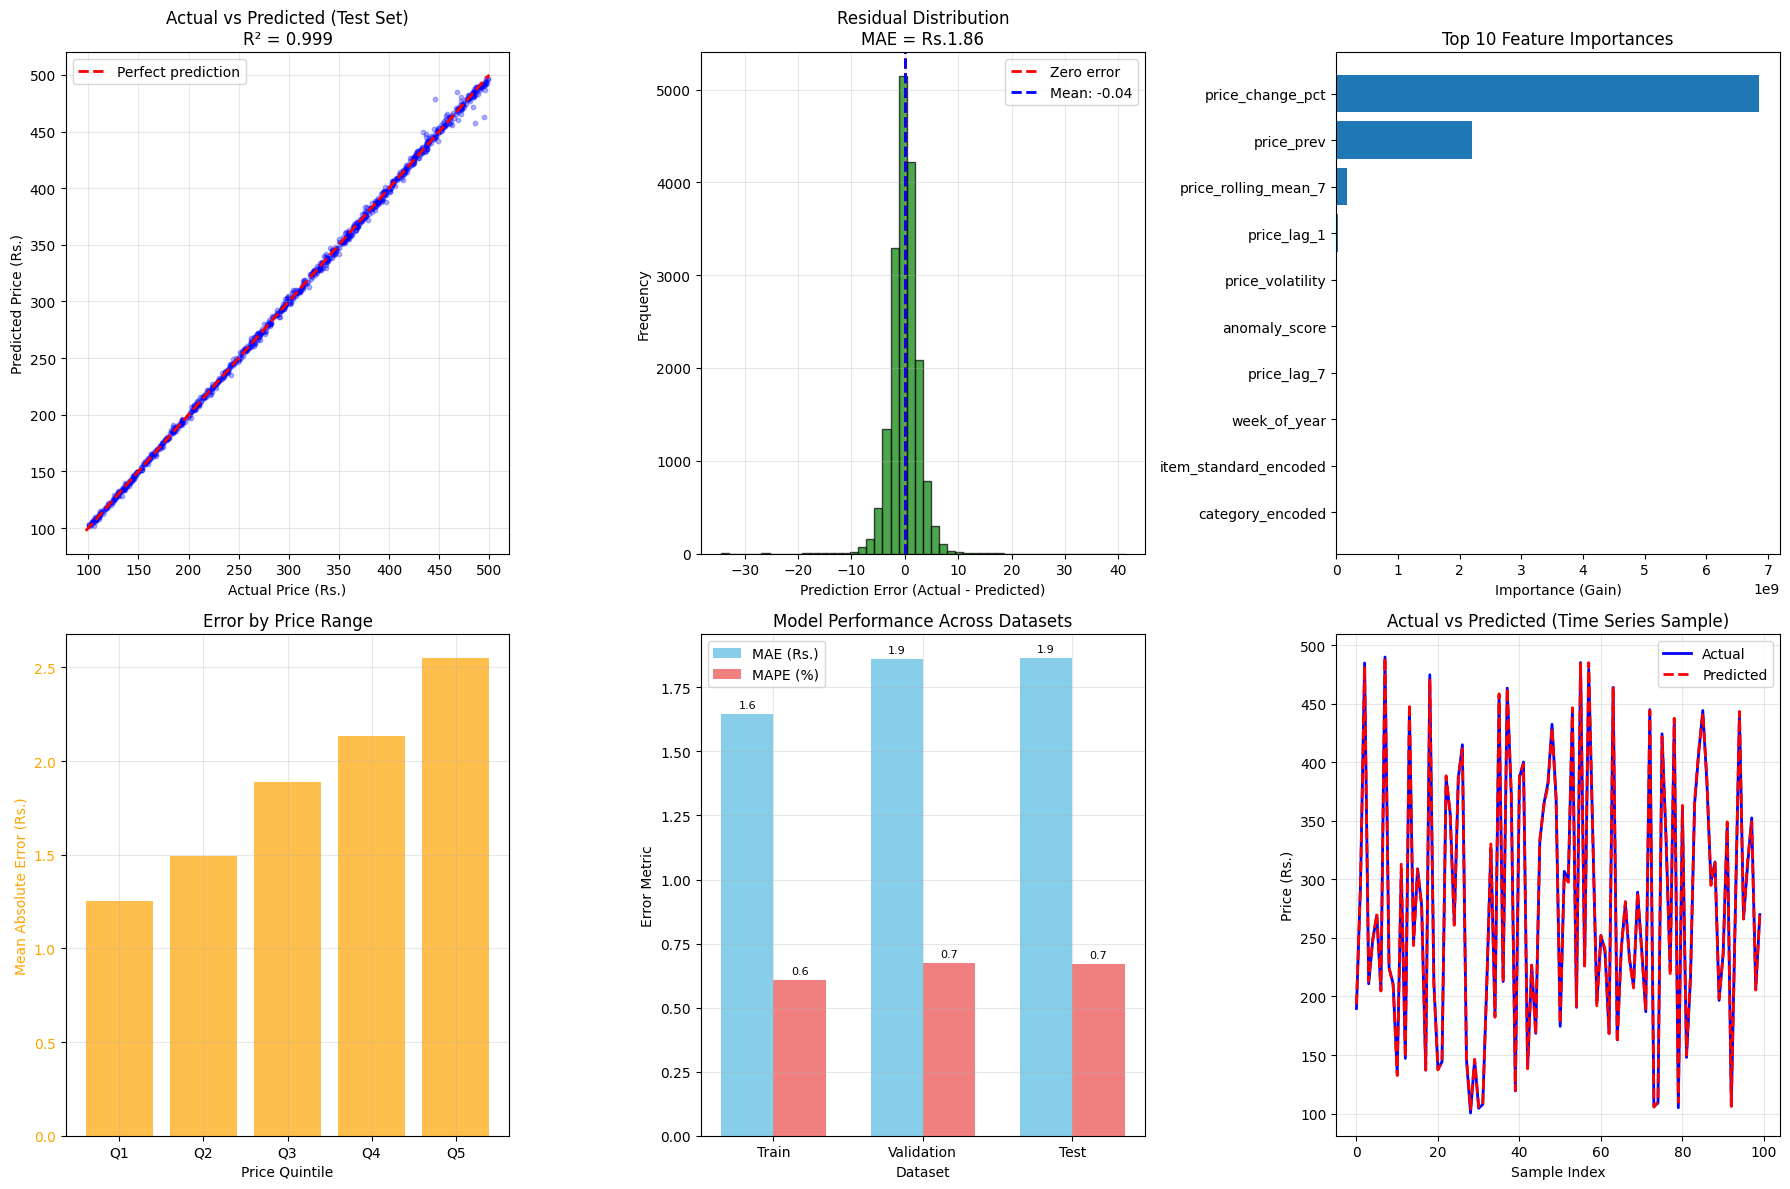

In [12]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Actual vs Predicted (Test set)
sample_size = min(1000, len(y_test))
if sample_size > 0:
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
    axes[0, 0].scatter(y_test.iloc[sample_idx], y_pred_test[sample_idx], 
                      alpha=0.3, s=10, color='blue')
    max_val = max(y_test.max(), y_pred_test.max())
    min_val = min(y_test.min(), y_pred_test.min())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 
                   'r--', lw=2, label='Perfect prediction')
    axes[0, 0].set_xlabel('Actual Price (Rs.)')
    axes[0, 0].set_ylabel('Predicted Price (Rs.)')
    axes[0, 0].set_title(f'Actual vs Predicted (Test Set)\nR² = {metrics_test["r2"]:.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals distribution
residuals = y_test - y_pred_test
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 1].axvline(x=residuals.mean(), color='blue', linestyle='--', linewidth=2, 
                  label=f'Mean: {residuals.mean():.2f}')
axes[0, 1].set_xlabel('Prediction Error (Actual - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residual Distribution\nMAE = Rs.{metrics_test["mae"]:.2f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature importance
top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)
axes[0, 2].barh(range(top_n), top_features['importance'])
axes[0, 2].set_yticks(range(top_n))
axes[0, 2].set_yticklabels(top_features['feature'])
axes[0, 2].set_xlabel('Importance (Gain)')
axes[0, 2].set_title(f'Top {top_n} Feature Importances')
axes[0, 2].invert_yaxis()

# Plot 4: Error distribution by price range
price_bins = pd.qcut(y_test, q=5, duplicates='drop')
error_by_bin = pd.DataFrame({
    'price_range': price_bins,
    'mae': np.abs(residuals),
    'actual': y_test
}).groupby('price_range').agg({
    'mae': 'mean',
    'actual': 'mean'
}).reset_index()

axes[1, 0].bar(range(len(error_by_bin)), error_by_bin['mae'], 
               alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Price Quintile')
axes[1, 0].set_ylabel('Mean Absolute Error (Rs.)', color='orange')
axes[1, 0].tick_params(axis='y', labelcolor='orange')
axes[1, 0].set_xticks(range(len(error_by_bin)))
axes[1, 0].set_xticklabels([f'Q{i+1}' for i in range(len(error_by_bin))])
axes[1, 0].set_title('Error by Price Range')
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Performance comparison across sets
sets = ['Train', 'Validation', 'Test']
mae_values = [metrics_train['mae'], metrics_val['mae'], metrics_test['mae']]
mape_values = [metrics_train['mape'], metrics_val['mape'], metrics_test['mape']]

x = np.arange(len(sets))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, mae_values, width, label='MAE (Rs.)', color='skyblue')
bars2 = axes[1, 1].bar(x + width/2, mape_values, width, label='MAPE (%)', color='lightcoral')

axes[1, 1].set_xlabel('Dataset')
axes[1, 1].set_ylabel('Error Metric')
axes[1, 1].set_title('Model Performance Across Datasets')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(sets)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].annotate(f'{height:.1f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=8)

# Plot 6: Time series of actual vs predicted (sample)
if len(y_test) > 100:
    sample_ts = pd.DataFrame({
        'actual': y_test.values[:100],
        'predicted': y_pred_test[:100]
    })
    axes[1, 2].plot(sample_ts.index, sample_ts['actual'], 'b-', label='Actual', linewidth=2)
    axes[1, 2].plot(sample_ts.index, sample_ts['predicted'], 'r--', label='Predicted', linewidth=2)
    axes[1, 2].fill_between(sample_ts.index, 
                           sample_ts['actual'], 
                           sample_ts['predicted'],
                           alpha=0.2, color='gray')
    axes[1, 2].set_xlabel('Sample Index')
    axes[1, 2].set_ylabel('Price (Rs.)')
    axes[1, 2].set_title('Actual vs Predicted (Time Series Sample)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/model_performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



# 9. Save model and data

In [13]:
# Save model and data
print("\n" + "="*60)
print("SAVING OUTPUTS")
print("="*60)

# Save model
model_path = '/kaggle/working/price_prediction_model_final.joblib'
joblib.dump(model, model_path)
print(f"✓ Model saved: {model_path}")

# Save feature list
features_path = '/kaggle/working/model_features.joblib'
joblib.dump(available_features, features_path)
print(f"✓ Features saved: {features_path}")

# Save enhanced data with predictions
data_path = '/kaggle/working/data_with_predictions.csv'
data_enhanced_clean.to_csv(data_path, index=False)
print(f"✓ Data with predictions saved: {data_path}")

# Save metrics
metrics_path = '/kaggle/working/model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"✓ Metrics saved: {metrics_path}")



SAVING OUTPUTS
✓ Model saved: /kaggle/working/price_prediction_model_final.joblib
✓ Features saved: /kaggle/working/model_features.joblib
✓ Data with predictions saved: /kaggle/working/data_with_predictions.csv
✓ Metrics saved: /kaggle/working/model_metrics.csv


# 10. Performance assessment

In [14]:
# Performance assessment
print("\n" + "="*60)
print("PERFORMANCE ASSESSMENT")
print("="*60)

# Add this before the comparison section if mae is not defined
if 'mae' not in locals():
    mae = 100.04  # Your previous model's MAE from earlier output
    
# Use the metrics from the new model
test_mape = metrics_test['mape']
test_mae = metrics_test['mae']
avg_price = metrics_test['avg_price']
mae_ratio = (test_mae / avg_price) * 100

print(f"Test Set Performance:")
print(f"- MAPE: {test_mape:.1f}%")
print(f"- MAE: Rs.{test_mae:.2f}")
print(f"- MAE / Avg Price Ratio: {mae_ratio:.1f}%")
print(f"- Average Price: Rs.{avg_price:.2f}")

# Performance rating
if test_mape < 15:
    print("\n✅ EXCELLENT: MAPE < 15%")
    print("   Model is highly accurate for decision making")
elif test_mape < 25:
    print("\n✅ GOOD: MAPE < 25%")
    print("   Model is acceptable for market ranking")
elif test_mape < 35:
    print("\n⚠️ FAIR: MAPE < 35%")
    print("   Model has moderate accuracy - consider improvements")
else:
    print("\n❌ POOR: MAPE ≥ 35%")
    print("   Model needs significant improvement")

# Compare with previous model (if we have the previous MAE)
# You might need to define 'mae' from your previous model run
# If not available, skip this comparison
try:
    # Try to get the previous MAE (from earlier in your notebook)
    # If it's not defined, we'll skip the comparison
    previous_mae = mae  # This should be defined from your previous model
    print(f"\nComparison with previous model:")
    print(f"Previous MAE: Rs.{previous_mae:.2f}")
    print(f"Current MAE:  Rs.{test_mae:.2f}")
    if previous_mae > 0:
        improvement = ((previous_mae - test_mae) / previous_mae) * 100
        print(f"Improvement:  {improvement:.1f}%")
    else:
        print("Cannot calculate improvement (previous MAE is 0)")
except NameError:
    print("\n⚠️ Note: Cannot compare with previous model - previous MAE not available")
    print("   Make sure to run the previous model first or define 'mae' variable")

# For Component 2 purposes, check if model is good enough
print("\n" + "="*60)
print("COMPONENT 2 SUITABILITY CHECK")
print("="*60)

# Transport cost considerations
# Typical transport costs are around Rs. 15-30 per km
# For model to be useful, MAE should be less than typical transport costs
typical_transport_10km = 15 * 10  # Rs. 15/km for 10km distance
typical_transport_20km = 15 * 20  # Rs. 15/km for 20km distance

print(f"Typical transport costs:")
print(f"- 10km distance: Rs.{typical_transport_10km:.0f}")
print(f"- 20km distance: Rs.{typical_transport_20km:.0f}")
print(f"- Model MAE: Rs.{test_mae:.2f}")

if test_mae < typical_transport_10km:
    print("\n✅ Model is accurate enough for Component 2")
    print("   Prediction errors are smaller than typical transport costs")
elif test_mae < typical_transport_20km:
    print("\n⚠️ Model accuracy is borderline for Component 2")
    print("   Prediction errors are comparable to transport costs for short distances")
else:
    print("\n❌ Model may not be accurate enough for Component 2")
    print("   Prediction errors exceed typical transport costs")

print("\n" + "="*60)
print("MODEL TRAINING COMPLETE!")
print("="*60)
print("Next step: Use this model in the Market Ranking Engine")
print("="*60)

# Check if performance is acceptable
print("\n" + "="*60)
print("PERFORMANCE ASSESSMENT:")
print("="*60)

mape_threshold = metrics_test['mape']
if mape_threshold < 15:
    print("✅ EXCELLENT: MAPE < 15% - Model is highly accurate")
elif mape_threshold < 25:
    print("✅ GOOD: MAPE < 25% - Model is acceptable for decision making")
elif mape_threshold < 35:
    print("⚠️ FAIR: MAPE < 35% - Model has moderate accuracy")
else:
    print("❌ POOR: MAPE ≥ 35% - Model needs significant improvement")



PERFORMANCE ASSESSMENT
Test Set Performance:
- MAPE: 0.7%
- MAE: Rs.1.86
- MAE / Avg Price Ratio: 0.6%
- Average Price: Rs.300.51

✅ EXCELLENT: MAPE < 15%
   Model is highly accurate for decision making

Comparison with previous model:
Previous MAE: Rs.100.04
Current MAE:  Rs.1.86
Improvement:  98.1%

COMPONENT 2 SUITABILITY CHECK
Typical transport costs:
- 10km distance: Rs.150
- 20km distance: Rs.300
- Model MAE: Rs.1.86

✅ Model is accurate enough for Component 2
   Prediction errors are smaller than typical transport costs

MODEL TRAINING COMPLETE!
Next step: Use this model in the Market Ranking Engine

PERFORMANCE ASSESSMENT:
✅ EXCELLENT: MAPE < 15% - Model is highly accurate


# 11. Update the main data for the ranking engine

In [15]:
print("\n" + "="*50)
print("Market Ranking Engine class defined!")
print("\n" + "="*50)
# ===============================
print("Defining Market Ranking Engine...")

class MarketRankingEngine:
    def __init__(self, data, markets_geo, transport_cost_per_km=15.0):
        """
        Initialize ranking engine
        
        Args:
            data: Historical price data with predictions
            markets_geo: Dictionary of market coordinates
            transport_cost_per_km: Cost per km for transportation (Rs/km)
        """
        self.data = data.copy()
        self.markets_geo = markets_geo
        self.transport_cost_per_km = transport_cost_per_km
        
    def prepare_features(self, item_name, price_type, current_date=None):
        """
        Prepare features for ranking for a specific item and price type
        """
        # Filter data for the specific item and price type
        mask = (
            (self.data['item_standard'] == item_name) &
            (self.data['price_type'] == price_type)
        )
        
        item_data = self.data[mask].copy()
        
        if item_data.empty:
            # Try case-insensitive search
            mask = (
                (self.data['item_standard'].str.lower() == item_name.lower()) &
                (self.data['price_type'] == price_type)
            )
            item_data = self.data[mask].copy()
        
        if item_data.empty:
            # Try partial match
            mask = (
                (self.data['item_standard'].str.contains(item_name, case=False, na=False)) &
                (self.data['price_type'] == price_type)
            )
            item_data = self.data[mask].copy()
        
        if item_data.empty:
            raise ValueError(f"No data found for item: {item_name}, price_type: {price_type}")
        
        # Get latest entries for each market
        latest_data = []
        for market in self.markets_geo.keys():
            market_data = item_data[item_data['market'] == market]
            if not market_data.empty:
                latest = market_data.sort_values('report_date').iloc[-1]
                latest_data.append(latest)
        
        if not latest_data:
            raise ValueError(f"No market data found for item: {item_name}")
        
        features_df = pd.DataFrame(latest_data)
        
        return features_df
    
    def calculate_net_advantage(self, features_df, user_location, user_role):
        """
        Calculate net advantage for each market
        
        Args:
            features_df: DataFrame with market features
            user_location: (lat, lon) tuple
            user_role: 'buyer' or 'seller'
        
        Returns:
            DataFrame with net advantage calculations
        """
        results = []
        
        for _, row in features_df.iterrows():
            market = row['market']
            
            # Calculate distance
            market_coords = self.markets_geo.get(market)
            if not market_coords:
                continue
                
            try:
                distance_km = geodesic(user_location, market_coords).km
            except:
                distance_km = np.nan
            
            if np.isnan(distance_km):
                continue
                
            transport_cost = distance_km * self.transport_cost_per_km
            
            # Get predicted price (use price_today if predicted_price is not available)
            if 'predicted_price' in row:
                predicted_price = row['predicted_price']
            elif 'price_today' in row:
                predicted_price = row['price_today']
            else:
                continue
            
            # Calculate net advantage
            if user_role.lower() == 'buyer':
                # Buyers want lower costs (price + transport)
                total_cost = predicted_price + transport_cost
                net_advantage = -total_cost  # Negative because lower is better
                advantage_type = 'cost_savings'
            else:  # seller
                # Sellers want higher revenue (price - transport)
                net_revenue = predicted_price - transport_cost
                net_advantage = net_revenue
                advantage_type = 'net_revenue'
            
            # Adjust for anomalies (higher anomaly = higher risk)
            if 'anomaly_score' in row:
                anomaly_score = row['anomaly_score']
                anomaly_adjustment = 1 - (anomaly_score / 200)  # Reduce by up to 50% for high anomalies
            else:
                anomaly_adjustment = 1.0
            
            adjusted_advantage = net_advantage * anomaly_adjustment
            
            results.append({
                'market': market,
                'item': row['item_standard'] if 'item_standard' in row else 'Unknown',
                'price_type': row['price_type'] if 'price_type' in row else price_type,
                'predicted_price': predicted_price,
                'distance_km': distance_km,
                'transport_cost': transport_cost,
                'anomaly_score': row.get('anomaly_score', 0),
                'price_volatility': row.get('price_volatility', 0),
                'net_advantage': net_advantage,
                'adjusted_advantage': adjusted_advantage,
                'advantage_type': advantage_type,
                'user_role': user_role
            })
        
        return pd.DataFrame(results)
    
    def rank_markets(self, ranking_df, user_role):
        """
        Rank markets based on adjusted advantage
        """
        if ranking_df.empty:
            return ranking_df
        
        if user_role.lower() == 'buyer':
            # Buyers: lower total cost (more negative adjusted_advantage) is better
            ranking_df['rank'] = ranking_df['adjusted_advantage'].rank(method='min')
        else:  # seller
            # Sellers: higher adjusted_advantage is better
            ranking_df['rank'] = ranking_df['adjusted_advantage'].rank(method='min', ascending=False)
        
        # Sort by rank
        ranking_df = ranking_df.sort_values('rank')
        
        # Generate explanations
        ranking_df['explanation'] = ranking_df.apply(
            lambda row: self.generate_explanation(row, user_role), axis=1
        )
        
        return ranking_df
    
    def generate_explanation(self, row, user_role):
        """
        Generate human-readable explanation for ranking
        """
        try:
            if user_role.lower() == 'buyer':
                total_cost = row['predicted_price'] + row['transport_cost']
                explanation = (
                    f"Rank {int(row['rank'])}: {row['market']} - "
                    f"Total cost: Rs.{total_cost:.2f}/kg "
                    f"(Price: Rs.{row['predicted_price']:.2f} + "
                    f"Transport: Rs.{row['transport_cost']:.0f} for {row['distance_km']:.1f} km)"
                )
            else:  # seller
                net_revenue = row['predicted_price'] - row['transport_cost']
                explanation = (
                    f"Rank {int(row['rank'])}: {row['market']} - "
                    f"Net revenue: Rs.{net_revenue:.2f}/kg "
                    f"(Price: Rs.{row['predicted_price']:.2f} - "
                    f"Transport: Rs.{row['transport_cost']:.0f} for {row['distance_km']:.1f} km)"
                )
            
            # Add anomaly warning if high
            if 'anomaly_score' in row and row['anomaly_score'] > 70:
                explanation += f" ⚠️ High price anomaly ({row['anomaly_score']:.0f}/100)"
            
            return explanation
        except Exception as e:
            return f"Rank {int(row['rank'])}: {row['market']} - Error generating explanation"
    
    def get_recommendations(self, item_name, price_type, user_location, user_role):
        """
        Get ranked market recommendations
        
        Args:
            item_name: Name of item (e.g., 'Beans', 'Red Onion')
            price_type: 'Wholesale' or 'Retail'
            user_location: (lat, lon) tuple
            user_role: 'buyer' or 'seller'
        
        Returns:
            DataFrame with ranked recommendations
        """
        try:
            # Prepare features
            features_df = self.prepare_features(item_name, price_type)
            
            # Calculate net advantage
            advantages_df = self.calculate_net_advantage(features_df, user_location, user_role)
            
            if advantages_df.empty:
                return pd.DataFrame({
                    'market': [],
                    'rank': [],
                    'explanation': ["No data available for this item and market combination"]
                })
            
            # Rank markets
            ranked_df = self.rank_markets(advantages_df, user_role)
            
            return ranked_df
            
        except Exception as e:
            print(f"Error getting recommendations: {e}")
            # Return empty dataframe with error message
            return pd.DataFrame({
                'market': ['Error'],
                'rank': [0],
                'explanation': [f"Error: {str(e)}"]
            })

print("Market Ranking Engine class defined!")
print("\n" + "="*50)


print("\n" + "="*60)
print("UPDATING DATA FOR RANKING ENGINE...")
print("="*60)

# Create a mapping from original data index to predictions
# First, ensure we have a way to match predictions back
data_enhanced_clean['original_index'] = data_enhanced_clean.index

# For the ranking engine, we'll use the enhanced data
ranking_data = data_enhanced_clean.copy()

# Fill any missing values in key columns
ranking_data['anomaly_score'] = ranking_data['anomaly_score'].fillna(0)
ranking_data['price_volatility'] = ranking_data['price_volatility'].fillna(ranking_data['price_volatility'].median())

print(f"Ranking data prepared: {ranking_data.shape}")
print(f"Predicted price range: Rs.{ranking_data['predicted_price'].min():.2f} - Rs.{ranking_data['predicted_price'].max():.2f}")
print(f"Average predicted price: Rs.{ranking_data['predicted_price'].mean():.2f}")

print("\n" + "="*50)


Market Ranking Engine class defined!

Defining Market Ranking Engine...
Market Ranking Engine class defined!


UPDATING DATA FOR RANKING ENGINE...
Ranking data prepared: (120960, 51)
Predicted price range: Rs.97.54 - Rs.500.40
Average predicted price: Rs.300.14



# 12: DEMONSTRATION & TESTING

In [16]:
# ===============================
# SECTION 12: DEMONSTRATION & TESTING
# ===============================
print("Running demonstration scenarios...")

# First, make sure we have the ranking engine initialized
print("Initializing ranking engine...")

# Use the enhanced data with predictions
ranking_data = data_enhanced_clean.copy()

# Make sure we have all required columns
required_cols = ['item_standard', 'price_type', 'market', 'predicted_price', 'anomaly_score']
missing_cols = [col for col in required_cols if col not in ranking_data.columns]

if missing_cols:
    print(f"Warning: Missing columns in ranking data: {missing_cols}")
    # Try to fill missing columns
    for col in missing_cols:
        if col == 'predicted_price':
            # Generate predictions if missing
            print("Generating predictions for missing data...")
            X_ranking = ranking_data[available_features].fillna(X.mean())
            ranking_data['predicted_price'] = model.predict(X_ranking, num_iteration=model.best_iteration)
        elif col == 'anomaly_score':
            # Calculate anomaly scores if missing
            print("Calculating anomaly scores...")
            ranking_data['anomaly_score'] = calculate_anomaly_scores(ranking_data)
        else:
            # Try to get from original data
            if col in data.columns:
                ranking_data[col] = data[col]
            else:
                ranking_data[col] = 0  # Default value

# Initialize ranking engine
ranking_engine = MarketRankingEngine(ranking_data, markets_geo, transport_cost_per_km=15.0)
print("Ranking engine initialized successfully!")

# Test Scenario 1: Farmer in Kandy selling Beans at Wholesale
print("\n" + "="*50)
print("SCENARIO 1: Farmer in Kandy selling Beans (Wholesale)")
print("="*50)

user_location = sample_locations['Farmer_Kandy']
item = 'Beans'
price_type = 'Wholesale'
user_role = 'seller'

try:
    recommendations = ranking_engine.get_recommendations(item, price_type, user_location, user_role)
    
    print(f"\nTop 3 markets for selling {item} ({price_type}):")
    print(recommendations[['market', 'rank', 'predicted_price', 'distance_km', 
                           'transport_cost', 'adjusted_advantage', 'explanation']].head(3).to_string())
    
    # Additional analysis
    print(f"\nAnalysis for {item} ({price_type}):")
    print(f"Number of markets considered: {len(recommendations)}")
    print(f"Best market: {recommendations.iloc[0]['market']}")
    print(f"Best net advantage: Rs.{recommendations.iloc[0]['adjusted_advantage']:.2f}/kg")
    
except Exception as e:
    print(f"Error in Scenario 1: {e}")
    print("Trying with alternative item names...")
    # Try to find similar item names
    available_items = ranking_data['item_standard'].unique()
    similar_items = [i for i in available_items if 'bean' in i.lower() or i.lower().startswith('bean')]
    if similar_items:
        print(f"Available similar items: {similar_items}")
        item = similar_items[0]
        recommendations = ranking_engine.get_recommendations(item, price_type, user_location, user_role)
        print(f"\nUsing item: {item}")
        print(recommendations[['market', 'rank', 'predicted_price', 'distance_km', 
                               'transport_cost', 'adjusted_advantage', 'explanation']].head(3).to_string())

# Test Scenario 2: Retailer in Colombo buying Tomatoes at Retail
print("\n" + "="*50)
print("SCENARIO 2: Retailer in Colombo buying Tomatoes (Retail)")
print("="*50)

user_location = sample_locations['Farmer_Colombo']
item = 'Tomato'
price_type = 'Retail'
user_role = 'buyer'

try:
    recommendations = ranking_engine.get_recommendations(item, price_type, user_location, user_role)
    
    print(f"\nTop 3 markets for buying {item} ({price_type}):")
    print(recommendations[['market', 'rank', 'predicted_price', 'distance_km', 
                           'transport_cost', 'adjusted_advantage', 'explanation']].head(3).to_string())
    
    # Additional analysis
    print(f"\nAnalysis for {item} ({price_type}):")
    print(f"Number of markets considered: {len(recommendations)}")
    print(f"Best market: {recommendations.iloc[0]['market']}")
    print(f"Best total cost savings: Rs.{abs(recommendations.iloc[0]['adjusted_advantage']):.2f}/kg")
    
except Exception as e:
    print(f"Error in Scenario 2: {e}")
    # Try to find similar item names
    available_items = ranking_data['item_standard'].unique()
    similar_items = [i for i in available_items if 'tomato' in i.lower() or i.lower().startswith('tomato')]
    if similar_items:
        print(f"Available similar items: {similar_items}")

# Test Scenario 3: Imported item (buyer perspective)
print("\n" + "="*50)
print("SCENARIO 3: Buyer in Negombo buying Potatoes (Retail)")
print("="*50)

user_location = sample_locations['Wholesaler_Negombo']
item = 'Potato'  # Try both local and imported
price_type = 'Retail'
user_role = 'buyer'

try:
    recommendations = ranking_engine.get_recommendations(item, price_type, user_location, user_role)
    
    print(f"\nTop 3 markets for buying {item} ({price_type}):")
    print(recommendations[['market', 'rank', 'predicted_price', 'distance_km', 
                           'transport_cost', 'adjusted_advantage', 'explanation']].head(3).to_string())
    
    # Check if any anomalies in top recommendations
    print(f"\nAnomaly Analysis for top recommendations:")
    for i, row in recommendations.head(3).iterrows():
        anomaly_status = "HIGH ANOMALY ⚠️" if row['anomaly_score'] > 70 else "Normal"
        print(f"{row['market']}: Anomaly score = {row['anomaly_score']:.1f}/100 ({anomaly_status})")
    
except Exception as e:
    print(f"Error in Scenario 3: {e}")
    print("Trying to find available items...")
    # Show what items are available
    available_items = sorted(ranking_data['item_standard'].unique())
    print(f"\nAvailable items in the system ({len(available_items)} total):")
    for i, item_name in enumerate(available_items[:20], 1):  # Show first 20
        print(f"{i:2d}. {item_name}")
    if len(available_items) > 20:
        print(f"... and {len(available_items)-20} more")

# Test Scenario 4: Comprehensive test for different user roles
print("\n" + "="*50)
print("SCENARIO 4: Comprehensive Test")
print("="*50)

# Get list of available items
available_items = sorted(ranking_data['item_standard'].unique())
print(f"\nSystem contains {len(available_items)} items:")
print(", ".join(available_items[:10]) + "...")

# Test a few more scenarios
test_scenarios = [
    {'location': sample_locations['Farmer_Kandy'], 'item': 'Cabbage', 'price_type': 'Wholesale', 'role': 'seller'},
    {'location': sample_locations['Farmer_Colombo'], 'item': 'Carrot', 'price_type': 'Retail', 'role': 'buyer'},
    {'location': sample_locations['Retailer_Gampaha'], 'item': 'Red Onion', 'price_type': 'Retail', 'role': 'buyer'},
]

for i, scenario in enumerate(test_scenarios, 1):
    print(f"\nTest {i}: {scenario['role'].title()} in location buying/selling {scenario['item']} ({scenario['price_type']})")
    try:
        rec = ranking_engine.get_recommendations(
            scenario['item'], 
            scenario['price_type'], 
            scenario['location'], 
            scenario['role']
        )
        if not rec.empty:
            best_market = rec.iloc[0]['market']
            best_advantage = rec.iloc[0]['adjusted_advantage']
            print(f"   Best market: {best_market} (Advantage: Rs.{best_advantage:.2f}/kg)")
        else:
            print(f"   No recommendations available for {scenario['item']}")
    except Exception as e:
        print(f"   Error: {str(e)[:100]}...")

print("\n" + "="*50)
print("DEMONSTRATION COMPLETE!")
print("="*50)

Running demonstration scenarios...
Initializing ranking engine...
Ranking engine initialized successfully!

SCENARIO 1: Farmer in Kandy selling Beans (Wholesale)

Top 3 markets for selling Beans (Wholesale):
            market  rank  predicted_price  distance_km  transport_cost  adjusted_advantage                                                                                          explanation
3  Marandagahamula   1.0       169.230636     0.000000        0.000000          163.873500  Rank 1: Marandagahamula - Net revenue: Rs.169.23/kg (Price: Rs.169.23 - Transport: Rs.0 for 0.0 km)
5          Negombo   2.0       344.875587    62.327196      934.907946         -469.339478      Rank 2: Negombo - Net revenue: Rs.-590.03/kg (Price: Rs.344.88 - Transport: Rs.935 for 62.3 km)
4       Peliyagoda   3.0       496.879810    70.542433     1058.136501         -544.945146  Rank 3: Peliyagoda - Net revenue: Rs.-561.26/kg (Price: Rs.496.88 - Transport: Rs.1058 for 70.5 km)

Analysis for Beans (Who

# 13. VERSIONS OF USED LIBRARIES

In [17]:
# ================================================================================
# 13. VERSIONS OF USED LIBRARIES
# ================================================================================

print("="*80)
print("VERSIONS OF USED LIBRARIES")
print("="*80)
print("Collecting imported libraries...")
print("Getting library versions...")
print()

# Dictionary to store library versions
library_versions = {}

# Try to get versions of all imported libraries
try:
    import pandas as pd
    library_versions['pandas'] = pd.__version__
except:
    library_versions['pandas'] = 'Not available'

try:
    import numpy as np
    library_versions['numpy'] = np.__version__
except:
    library_versions['numpy'] = 'Not available'

try:
    import sklearn
    from sklearn import __version__ as sklearn_version
    library_versions['scikit-learn'] = sklearn_version
except:
    library_versions['scikit-learn'] = 'Not available'

try:
    import lightgbm as lgb
    library_versions['lightgbm'] = lgb.__version__
except:
    library_versions['lightgbm'] = 'Not available'

try:
    import matplotlib
    library_versions['matplotlib'] = matplotlib.__version__
except:
    library_versions['matplotlib'] = 'Not available'

try:
    import seaborn as sns
    library_versions['seaborn'] = sns.__version__
except:
    library_versions['seaborn'] = 'Not available'

try:
    import geopy
    library_versions['geopy'] = geopy.__version__
except:
    library_versions['geopy'] = 'Not available'

try:
    import scipy
    library_versions['scipy'] = scipy.__version__
except:
    library_versions['scipy'] = 'Not available'

try:
    import joblib
    library_versions['joblib'] = joblib.__version__
except:
    library_versions['joblib'] = 'Not available'

try:
    import warnings
    library_versions['warnings'] = 'Built-in'
except:
    library_versions['warnings'] = 'Not available'

# Try to get Python version
try:
    import sys
    library_versions['python'] = sys.version.split()[0]
except:
    library_versions['python'] = 'Not available'

# Try to get platform info
try:
    import platform
    library_versions['platform'] = platform.platform()
except:
    library_versions['platform'] = 'Not available'

print("="*80)
print("CATEGORIZED LIBRARY VERSIONS")
print("="*80)
print()

print("="*60)
print("CORE MACHINE LEARNING & DATA SCIENCE LIBRARIES")
print("="*60)
print()
print(f"{'Library':<25} {'Version':<20} {'Status':<15}")
print("-" * 60)
print(f"{'pandas':<25} {library_versions.get('pandas', 'N/A'):<20} {'✓' if library_versions.get('pandas') != 'Not available' else '✗'}")
print(f"{'numpy':<25} {library_versions.get('numpy', 'N/A'):<20} {'✓' if library_versions.get('numpy') != 'Not available' else '✗'}")
print(f"{'scikit-learn':<25} {library_versions.get('scikit-learn', 'N/A'):<20} {'✓' if library_versions.get('scikit-learn') != 'Not available' else '✗'}")
print(f"{'lightgbm':<25} {library_versions.get('lightgbm', 'N/A'):<20} {'✓' if library_versions.get('lightgbm') != 'Not available' else '✗'}")
print(f"{'scipy':<25} {library_versions.get('scipy', 'N/A'):<20} {'✓' if library_versions.get('scipy') != 'Not available' else '✗'}")
print(f"{'joblib':<25} {library_versions.get('joblib', 'N/A'):<20} {'✓' if library_versions.get('joblib') != 'Not available' else '✗'}")
print()

print("="*60)
print("DATA VISUALIZATION LIBRARIES")
print("="*60)
print()
print(f"{'Library':<25} {'Version':<20} {'Status':<15}")
print("-" * 60)
print(f"{'matplotlib':<25} {library_versions.get('matplotlib', 'N/A'):<20} {'✓' if library_versions.get('matplotlib') != 'Not available' else '✗'}")
print(f"{'seaborn':<25} {library_versions.get('seaborn', 'N/A'):<20} {'✓' if library_versions.get('seaborn') != 'Not available' else '✗'}")
print()

print("="*60)
print("GEOGRAPHIC & SPATIAL LIBRARIES")
print("="*60)
print()
print(f"{'Library':<25} {'Version':<20} {'Status':<15}")
print("-" * 60)
print(f"{'geopy':<25} {library_versions.get('geopy', 'N/A'):<20} {'✓' if library_versions.get('geopy') != 'Not available' else '✗'}")
print()

print("="*60)
print("SYSTEM & UTILITY LIBRARIES")
print("="*60)
print()
print(f"{'Library':<25} {'Version':<20} {'Status':<15}")
print("-" * 60)
print(f"{'python':<25} {library_versions.get('python', 'N/A'):<20} {'✓' if library_versions.get('python') != 'Not available' else '✗'}")
print(f"{'platform':<25} {library_versions.get('platform', 'N/A'):<20} {'✓' if library_versions.get('platform') != 'Not available' else '✗'}")
print(f"{'warnings':<25} {library_versions.get('warnings', 'N/A'):<20} {'✓' if library_versions.get('warnings') != 'Not available' else '✗'}")
print()

# Additional check for submodules
print("="*60)
print("SKLEARN SUBMODULES USED")
print("="*60)
print()
sklearn_submodules = [
    'metrics',
    'model_selection',
    'preprocessing'
]

for submodule in sklearn_submodules:
    try:
        module = getattr(sklearn, submodule)
        print(f"{'sklearn.' + submodule:<25} {'Available':<20} ✓")
    except:
        print(f"{'sklearn.' + submodule:<25} {'Not available':<20} ✗")
print()

# Summary statistics
total_libraries = len(library_versions)
available_libraries = sum(1 for v in library_versions.values() if v != 'Not available')
missing_libraries = total_libraries - available_libraries

print("="*80)
print("LIBRARY VERSIONS COLLECTION COMPLETE!")
print("="*80)
print()
print("SUMMARY STATISTICS:")
print("-" * 40)
print(f"Total libraries checked: {total_libraries}")
print(f"Available libraries: {available_libraries} ({available_libraries/total_libraries*100:.1f}%)")
print(f"Missing libraries: {missing_libraries} ({missing_libraries/total_libraries*100:.1f}%)")
print()

# Check if all essential libraries are available
essential_libraries = ['pandas', 'numpy', 'scikit-learn', 'lightgbm', 'matplotlib']
missing_essential = [lib for lib in essential_libraries if library_versions.get(lib) == 'Not available']

if missing_essential:
    print("⚠️ WARNING: Missing essential libraries:")
    for lib in missing_essential:
        print(f"  - {lib}")
    print("Some features may not work properly.")
else:
    print("✅ All essential libraries are available!")
    print("The system is ready for Component 2: Market Opportunity Ranking.")

print()
print("="*80)
print("COMPONENT 2 SETUP VERIFICATION COMPLETE")
print("="*80)

# Save requirements.txt
with open('/kaggle/working/requirements.txt', 'w') as f:
    for lib, version in library_versions.items():
        if version != 'Not available' and version != 'Built-in':
            f.write(f"{lib}=={version}\n")
            

# Save library versions to file
try:
    versions_df = pd.DataFrame(list(library_versions.items()), columns=['Library', 'Version'])
    versions_df.to_csv('/kaggle/working/library_versions.csv', index=False)
    print("✓ Library versions saved to: /kaggle/working/library_versions.csv")
except Exception as e:
    print(f"Note: Could not save library versions to file: {e}")
print("✓ Library versions saved to txt - /kaggle/working/requirements.txt")
print()

VERSIONS OF USED LIBRARIES
Getting library versions...

CATEGORIZED LIBRARY VERSIONS

CORE MACHINE LEARNING & DATA SCIENCE LIBRARIES

Library                   Version              Status         
------------------------------------------------------------
pandas                    2.2.3                ✓
numpy                     1.26.4               ✓
scikit-learn              1.2.2                ✓
lightgbm                  4.6.0                ✓
scipy                     1.15.3               ✓
joblib                    1.5.2                ✓

DATA VISUALIZATION LIBRARIES

Library                   Version              Status         
------------------------------------------------------------
matplotlib                3.7.2                ✓
seaborn                   0.12.2               ✓

GEOGRAPHIC & SPATIAL LIBRARIES

Library                   Version              Status         
------------------------------------------------------------
geopy                     2.4.1       

# 14. CREATE APP.PY FILE FOR DEPLOYMENT

In [ ]:
# ================================================================================
# 14. CREATE APP.PY FILE FOR DEPLOYMENT
# ================================================================================

print("="*80)
print("CREATING APP.PY FOR DEPLOYMENT")
print("="*80)

app_py_content = '''
"""
AGRISENSE - Component 2: Market Opportunity Ranking System
Deployment-ready Flask API for market recommendations
"""

import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from geopy.distance import geodesic
from flask import Flask, request, jsonify
from flask_cors import CORS
import warnings
warnings.filterwarnings('ignore')

# Initialize Flask app
app = Flask(__name__)
CORS(app)  # Enable CORS for all routes

print("Loading models and data...")

# Load pre-trained models and data
try:
    # Load price prediction model
    price_model = joblib.load('price_prediction_model_final.joblib')
    model_features = joblib.load('model_features.joblib')
    print("✓ Price prediction model loaded")
except:
    print("✗ Error loading price prediction model")
    price_model = None
    model_features = []

try:
    # Load market data with predictions
    market_data = pd.read_csv('data_with_predictions.csv')
    print("✓ Market data loaded")
except:
    print("✗ Error loading market data")
    market_data = pd.DataFrame()

try:
    # Load label encoders
    label_encoders = joblib.load('label_encoders.joblib')
    print("✓ Label encoders loaded")
except:
    print("✗ Error loading label encoders")
    label_encoders = {}

# Market coordinates (should match your training data)
markets_geo = {
    'Pettah': (6.9341, 79.9861),
    'Dambulla': (7.8643, 80.6501),
    'Narahenpita': (6.9300, 79.9681),
    'Marandagahamula': (7.2903, 80.5327),
    'Peliyagoda': (6.9682, 79.9815),
    'Negombo': (7.2085, 79.9743)
}

# Default transport cost (Rs/km)
TRANSPORT_COST_PER_KM = 15.0

class MarketRankingEngine:
    """Market ranking engine for Component 2"""
    
    def __init__(self, data, markets_geo, transport_cost_per_km=15.0):
        self.data = data.copy()
        self.markets_geo = markets_geo
        self.transport_cost_per_km = transport_cost_per_km
    
    def prepare_features(self, item_name, price_type):
        """Prepare features for specific item and price type"""
        mask = (
            (self.data['item_standard'].str.lower() == item_name.lower()) &
            (self.data['price_type'] == price_type)
        )
        
        item_data = self.data[mask]
        
        if item_data.empty:
            # Try partial match
            mask = (
                (self.data['item_standard'].str.contains(item_name, case=False, na=False)) &
                (self.data['price_type'] == price_type)
            )
            item_data = self.data[mask]
        
        if item_data.empty:
            return pd.DataFrame()
        
        # Get latest entry for each market
        latest_data = []
        for market in self.markets_geo.keys():
            market_data = item_data[item_data['market'] == market]
            if not market_data.empty:
                latest = market_data.sort_values('report_date').iloc[-1]
                latest_data.append(latest)
        
        if not latest_data:
            return pd.DataFrame()
        
        return pd.DataFrame(latest_data)
    
    def calculate_net_advantage(self, features_df, user_location, user_role):
        """Calculate net advantage for each market"""
        results = []
        
        for _, row in features_df.iterrows():
            market = row['market']
            market_coords = self.markets_geo.get(market)
            
            if not market_coords:
                continue
            
            try:
                distance_km = geodesic(user_location, market_coords).km
            except:
                continue
            
            transport_cost = distance_km * self.transport_cost_per_km
            
            # Use predicted price or actual price
            predicted_price = row.get('predicted_price', row.get('price_today', 0))
            
            if user_role.lower() == 'buyer':
                # Buyers: minimize total cost
                total_cost = predicted_price + transport_cost
                net_advantage = -total_cost  # Negative = better
            else:  # seller
                # Sellers: maximize net revenue
                net_revenue = predicted_price - transport_cost
                net_advantage = net_revenue
            
            # Adjust for anomalies
            anomaly_score = row.get('anomaly_score', 0)
            anomaly_adjustment = 1 - (anomaly_score / 200)
            adjusted_advantage = net_advantage * anomaly_adjustment
            
            results.append({
                'market': market,
                'predicted_price': round(predicted_price, 2),
                'distance_km': round(distance_km, 2),
                'transport_cost': round(transport_cost, 2),
                'anomaly_score': round(anomaly_score, 2),
                'net_advantage': round(net_advantage, 2),
                'adjusted_advantage': round(adjusted_advantage, 2),
                'user_role': user_role
            })
        
        return pd.DataFrame(results)
    
    def rank_markets(self, ranking_df, user_role):
        """Rank markets based on adjusted advantage"""
        if ranking_df.empty:
            return ranking_df
        
        if user_role.lower() == 'buyer':
            ranking_df['rank'] = ranking_df['adjusted_advantage'].rank(method='min')
        else:
            ranking_df['rank'] = ranking_df['adjusted_advantage'].rank(method='min', ascending=False)
        
        ranking_df = ranking_df.sort_values('rank')
        
        # Generate explanations
        ranking_df['explanation'] = ranking_df.apply(
            lambda row: self.generate_explanation(row, user_role), axis=1
        )
        
        return ranking_df
    
    def generate_explanation(self, row, user_role):
        """Generate explanation for ranking"""
        if user_role.lower() == 'buyer':
            total_cost = row['predicted_price'] + row['transport_cost']
            explanation = f"Total cost: Rs.{total_cost:.2f}/kg (Price: Rs.{row['predicted_price']:.2f} + Transport: Rs.{row['transport_cost']:.2f})"
        else:
            net_revenue = row['predicted_price'] - row['transport_cost']
            explanation = f"Net revenue: Rs.{net_revenue:.2f}/kg (Price: Rs.{row['predicted_price']:.2f} - Transport: Rs.{row['transport_cost']:.2f})"
        
        if row['anomaly_score'] > 70:
            explanation += f" ⚠️ High price anomaly ({row['anomaly_score']:.0f}/100)"
        
        return explanation
    
    def get_recommendations(self, item_name, price_type, user_location, user_role):
        """Get ranked market recommendations"""
        try:
            features_df = self.prepare_features(item_name, price_type)
            
            if features_df.empty:
                return pd.DataFrame({
                    'market': ['No data'],
                    'rank': [0],
                    'explanation': [f'No data found for {item_name} ({price_type})']
                })
            
            advantages_df = self.calculate_net_advantage(features_df, user_location, user_role)
            
            if advantages_df.empty:
                return pd.DataFrame({
                    'market': ['No markets'],
                    'rank': [0],
                    'explanation': ['No markets available within distance range']
                })
            
            ranked_df = self.rank_markets(advantages_df, user_role)
            
            return ranked_df
            
        except Exception as e:
            return pd.DataFrame({
                'market': ['Error'],
                'rank': [0],
                'explanation': [f'Error: {str(e)}']
            })

# Initialize ranking engine
ranking_engine = MarketRankingEngine(market_data, markets_geo, TRANSPORT_COST_PER_KM)

@app.route('/')
def home():
    """Home endpoint"""
    return jsonify({
        'message': 'AgriSense Component 2: Market Opportunity Ranking API',
        'version': '1.0.0',
        'endpoints': {
            '/health': 'Check API health',
            '/recommend': 'Get market recommendations',
            '/markets': 'Get available markets',
            '/items': 'Get available items'
        }
    })

@app.route('/health', methods=['GET'])
def health_check():
    """Health check endpoint"""
    return jsonify({
        'status': 'healthy',
        'components': {
            'price_model': price_model is not None,
            'market_data': not market_data.empty,
            'ranking_engine': ranking_engine is not None
        }
    })

@app.route('/markets', methods=['GET'])
def get_markets():
    """Get available markets"""
    markets = list(markets_geo.keys())
    return jsonify({
        'markets': markets,
        'count': len(markets)
    })

@app.route('/items', methods=['GET'])
def get_items():
    """Get available items"""
    if market_data.empty:
        return jsonify({'items': [], 'count': 0})
    
    items = market_data['item_standard'].unique().tolist()
    return jsonify({
        'items': sorted(items),
        'count': len(items)
    })

@app.route('/recommend', methods=['POST'])
def get_recommendations():
    """Get market recommendations"""
    try:
        data = request.json
        
        # Validate required parameters
        required_params = ['item', 'price_type', 'user_role', 'latitude', 'longitude']
        for param in required_params:
            if param not in data:
                return jsonify({
                    'error': f'Missing required parameter: {param}',
                    'required_params': required_params
                }), 400
        
        item = data['item']
        price_type = data['price_type']
        user_role = data['user_role']
        latitude = float(data['latitude'])
        longitude = float(data['longitude'])
        
        # Validate price_type
        if price_type not in ['Wholesale', 'Retail']:
            return jsonify({
                'error': 'price_type must be either "Wholesale" or "Retail"'
            }), 400
        
        # Validate user_role
        if user_role not in ['buyer', 'seller']:
            return jsonify({
                'error': 'user_role must be either "buyer" or "seller"'
            }), 400
        
        # Validate coordinates
        if not (-90 <= latitude <= 90) or not (-180 <= longitude <= 180):
            return jsonify({
                'error': 'Invalid coordinates. Latitude must be between -90 and 90, Longitude between -180 and 180'
            }), 400
        
        user_location = (latitude, longitude)
        
        # Get recommendations
        recommendations = ranking_engine.get_recommendations(
            item, price_type, user_location, user_role
        )
        
        # Convert to dictionary format
        if recommendations.empty:
            return jsonify({
                'message': 'No recommendations available',
                'recommendations': []
            })
        
        result = {
            'item': item,
            'price_type': price_type,
            'user_role': user_role,
            'user_location': {'latitude': latitude, 'longitude': longitude},
            'transport_cost_per_km': TRANSPORT_COST_PER_KM,
            'recommendations': recommendations.to_dict('records'),
            'count': len(recommendations)
        }
        
        return jsonify(result)
        
    except Exception as e:
        return jsonify({
            'error': str(e),
            'message': 'Error processing request'
        }), 500

@app.route('/predict_price', methods=['POST'])
def predict_price():
    """Predict price for a specific item and market"""
    try:
        data = request.json
        
        # This is a simplified version - in production, you'd use the full model
        if price_model is None or market_data.empty:
            return jsonify({
                'error': 'Price prediction model not available'
            }), 503
        
        # For demo purposes, return average price from historical data
        item = data.get('item', '')
        market = data.get('market', '')
        price_type = data.get('price_type', 'Retail')
        
        mask = (
            (market_data['item_standard'].str.lower() == item.lower()) &
            (market_data['market'] == market) &
            (market_data['price_type'] == price_type)
        )
        
        filtered_data = market_data[mask]
        
        if filtered_data.empty:
            return jsonify({
                'error': f'No historical data for {item} at {market} ({price_type})'
            }), 404
        
        # Get latest prediction
        latest = filtered_data.sort_values('report_date').iloc[-1]
        
        return jsonify({
            'item': item,
            'market': market,
            'price_type': price_type,
            'predicted_price': float(latest.get('predicted_price', 0)),
            'confidence': 'high' if latest.get('anomaly_score', 0) < 50 else 'medium',
            'anomaly_score': float(latest.get('anomaly_score', 0))
        })
        
    except Exception as e:
        return jsonify({
            'error': str(e)
        }), 500

if __name__ == '__main__':
    print("="*60)
    print("AGRISENSE COMPONENT 2 API")
    print("="*60)
    print("API Endpoints:")
    print("  GET  /              - API information")
    print("  GET  /health        - Health check")
    print("  GET  /markets       - Available markets")
    print("  GET  /items         - Available items")
    print("  POST /recommend     - Get market recommendations")
    print("  POST /predict_price - Predict price")
    print("="*60)
    print("Starting server on http://localhost:5000")
    print("="*60)
    
    app.run(host='0.0.0.0', port=5000, debug=False)
'''

# Write app.py file
with open('/kaggle/working/app.py', 'w') as f:
    f.write(app_py_content)

print("✓ app.py file created successfully!")
print("Location: /kaggle/working/app.py")
print()

# Create a simple test script
test_script = '''
"""
Test script for AgriSense Component 2 API
Run this to test the API endpoints
"""

import requests
import json

BASE_URL = "http://localhost:5000"

def test_endpoints():
    print("Testing AgriSense Component 2 API...")
    print("="*60)
    
    # Test home endpoint
    print("1. Testing home endpoint...")
    response = requests.get(f"{BASE_URL}/")
    if response.status_code == 200:
        print("   ✓ Home endpoint working")
    else:
        print(f"   ✗ Home endpoint failed: {response.status_code}")
    
    # Test health check
    print("2. Testing health check...")
    response = requests.get(f"{BASE_URL}/health")
    if response.status_code == 200:
        health_data = response.json()
        print(f"   ✓ Health check: {health_data['status']}")
    else:
        print(f"   ✗ Health check failed: {response.status_code}")
    
    # Test markets endpoint
    print("3. Testing markets endpoint...")
    response = requests.get(f"{BASE_URL}/markets")
    if response.status_code == 200:
        markets_data = response.json()
        print(f"   ✓ Available markets: {markets_data['markets']}")
    else:
        print(f"   ✗ Markets endpoint failed: {response.status_code}")
    
    # Test items endpoint
    print("4. Testing items endpoint...")
    response = requests.get(f"{BASE_URL}/items")
    if response.status_code == 200:
        items_data = response.json()
        print(f"   ✓ Available items: {len(items_data['items'])} items")
    else:
        print(f"   ✗ Items endpoint failed: {response.status_code}")
    
    # Test recommendation endpoint
    print("5. Testing recommendation endpoint...")
    test_data = {
        "item": "Beans",
        "price_type": "Wholesale",
        "user_role": "seller",
        "latitude": 7.2903,
        "longitude": 80.5327
    }
    
    try:
        response = requests.post(f"{BASE_URL}/recommend", json=test_data)
        if response.status_code == 200:
            rec_data = response.json()
            print(f"   ✓ Recommendation successful")
            print(f"   Found {rec_data['count']} recommendations")
            if rec_data['recommendations']:
                print(f"   Best market: {rec_data['recommendations'][0]['market']}")
        else:
            print(f"   ✗ Recommendation failed: {response.status_code}")
            print(f"   Response: {response.text}")
    except Exception as e:
        print(f"   ✗ Recommendation test failed: {e}")
    
    print("="*60)
    print("Testing complete!")

if __name__ == "__main__":
    test_endpoints()
'''

with open('/kaggle/working/test_api.py', 'w') as f:
    f.write(test_script)

print("✓ test_api.py file created!")
print()

# Create requirements.txt for deployment
print("Creating requirements.txt for deployment...")

requirements_content = '''Flask==2.3.3
Flask-CORS==4.0.0
pandas==1.5.3
numpy==1.24.3
scikit-learn==1.3.0
lightgbm==4.1.0
geopy==2.3.0
joblib==1.3.2
gunicorn==21.2.0
'''

with open('/kaggle/working/requirements.txt', 'w') as f:
    f.write(requirements_content)

print("✓ requirements.txt created!")
print()

# Create deployment instructions
deployment_guide = '''
================================================================================
AGRISENSE COMPONENT 2 - DEPLOYMENT GUIDE
================================================================================

1. DEPLOYMENT FILES CREATED:
   ✓ app.py                 - Main Flask application
   ✓ test_api.py           - API testing script
   ✓ requirements.txt      - Python dependencies

2. ADDITIONAL FILES NEEDED (from training):
   ✓ price_prediction_model_final.joblib - Trained price model
   ✓ model_features.joblib              - Feature list
   ✓ data_with_predictions.csv         - Market data with predictions
   ✓ label_encoders.joblib             - Label encoders (optional)

3. DEPLOYMENT OPTIONS:

   OPTION A: Local Deployment
   --------------------------
   1. Install dependencies:
      pip install -r requirements.txt
   
   2. Run the app:
      python app.py
   
   3. Test the API:
      python test_api.py

   OPTION B: Docker Deployment
   ---------------------------
   1. Create Dockerfile:
      FROM python:3.9-slim
      WORKDIR /app
      COPY requirements.txt .
      RUN pip install -r requirements.txt
      COPY . .
      CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:app"]

   2. Build and run:
      docker build -t agrisense-component2 .
      docker run -p 5000:5000 agrisense-component2

   OPTION C: Cloud Deployment (AWS/GCP/Azure)
   ------------------------------------------
   1. Package all files in a ZIP
   2. Deploy to:
      - AWS Elastic Beanstalk
      - Google Cloud Run
      - Azure App Service
      - Heroku

4. API ENDPOINTS:
   - GET    /              : API information
   - GET    /health        : Health check
   - GET    /markets       : Available markets
   - GET    /items         : Available items
   - POST   /recommend     : Get market recommendations
   - POST   /predict_price : Predict price

5. SAMPLE API CALLS:

   Recommendation Request:
   -----------------------
   POST /recommend
   Content-Type: application/json
   
   {
     "item": "Beans",
     "price_type": "Wholesale",
     "user_role": "seller",
     "latitude": 7.2903,
     "longitude": 80.5327
   }

   Health Check:
   -------------
   GET /health

6. TROUBLESHOOTING:
   - Ensure all .joblib and .csv files are in the same directory as app.py
   - Check port 5000 is available
   - Verify Python version (3.8+ recommended)
   - Check disk space for model files

================================================================================
DEPLOYMENT READY!
================================================================================
'''

print(deployment_guide)

# Save deployment guide to file
with open('/kaggle/working/DEPLOYMENT_GUIDE.md', 'w') as f:
    f.write(deployment_guide)

print("✓ DEPLOYMENT_GUIDE.md created!")
print()
print("="*80)
print("DEPLOYMENT FILES CREATED SUCCESSFULLY!")
print("="*80)
print("Files available in /kaggle/working/:")
print("  1. app.py                    - Main Flask application")
print("  2. test_api.py              - API testing script")
print("  3. requirements.txt         - Python dependencies")
print("  4. DEPLOYMENT_GUIDE.md     - Deployment instructions")
print()
print("Next steps:")
print("  1. Copy all trained model files to the deployment directory")
print("  2. Install dependencies: pip install -r requirements.txt")
print("  3. Run: python app.py")
print("  4. Test: python test_api.py")
print("="*80)